#### Step 0：模型假設（precision parameterization）

對每一筆資料 \( i = 1, ....., n \)：

$$
y_i \mid \mu_i, t \sim \mathcal{N}(\mu_i, 1/t)
$$

其中

$$
\mu_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip}
$$

這裡：

- \($ y_i \ $)：wine quality  
- \($ \mu_i \ $)：第 \( i \) 筆資料的平均值  
- \( t \)：precision  
- variance  = 1/t 

##### Prior

$$
\beta_j \sim \mathcal{N}(0, 0.0001)
$$

$$
t \sim \text{Gamma}(\alpha, \beta)
$$

In [2]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
e:\Bayesian\01_Bayesian Linear Regression_MCMC\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [4]:
df = pd.read_csv("../data/winequality-red.csv", sep=";")

X = df.drop("quality", axis=1)
y = df["quality"].values

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [6]:
tau_beta = 0.0001   # prior precision for coefficients
alpha_t = 0.001     # prior shape for precision
beta_t = 0.001      # prior rate for precision

In [7]:
with pm.Model() as bayes_lm_precision:

    # Intercept prior
    beta_0 = pm.Normal(
        "beta_0",
        mu=0,
        tau=tau_beta
    )

    # Coefficient priors
    beta = pm.Normal(
        "beta",
        mu=0,
        tau=tau_beta,
        shape=X_scaled.shape[1]
    )

    # Precision prior
    t = pm.Gamma(
        "t",
        alpha=alpha_t,
        beta=beta_t
    )

    # Convert precision to sigma
    sigma = pm.Deterministic("sigma", 1 / pm.math.sqrt(t))

    # Linear predictor
    mu = beta_0 + pm.math.dot(X_scaled.values, beta)

    # Likelihood
    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y
    )

In [8]:
with bayes_lm_precision:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta, t]


e:\Bayesian\01_Bayesian Linear Regression_MCMC\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1474 seconds.


In [9]:
az.summary(trace, var_names=["beta_0", "beta", "t", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,5.636,0.016,5.605,5.665,0.000,0.000,10895.0,5741.0,1.0
beta[0],0.044,0.045,-0.037,0.133,0.001,0.000,4198.0,5161.0,1.0
beta[1],-0.194,0.022,-0.235,-0.153,0.000,0.000,7969.0,5843.0,1.0
beta[2],-0.036,0.029,-0.091,0.017,0.000,0.000,7821.0,5696.0,1.0
beta[3],0.023,0.021,-0.017,0.061,0.000,0.000,6354.0,6105.0,1.0
beta[4],-0.088,0.020,-0.127,-0.052,0.000,0.000,8800.0,6221.0,1.0
beta[5],0.045,0.022,0.003,0.087,0.000,0.000,8174.0,5885.0,1.0
beta[6],-0.107,0.024,-0.150,-0.061,0.000,0.000,7234.0,6334.0,1.0
beta[7],-0.034,0.041,-0.108,0.045,0.001,0.000,4095.0,5172.0,1.0
beta[8],-0.063,0.029,-0.117,-0.007,0.000,0.000,5039.0,6059.0,1.0


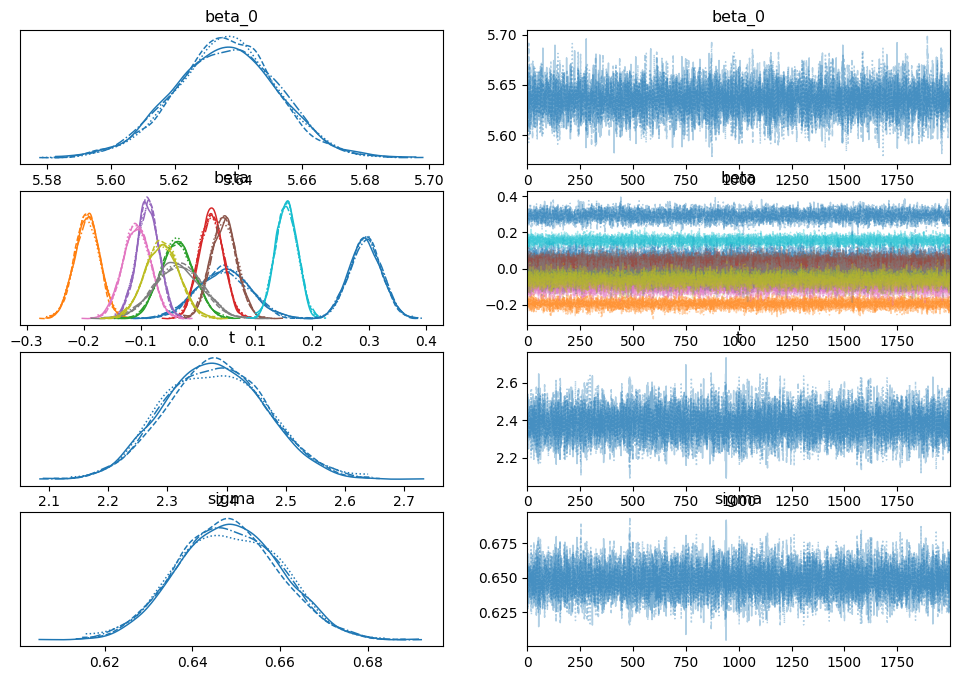

In [10]:
az.plot_trace(trace, var_names=["beta_0", "beta", "t", "sigma"])
plt.show()

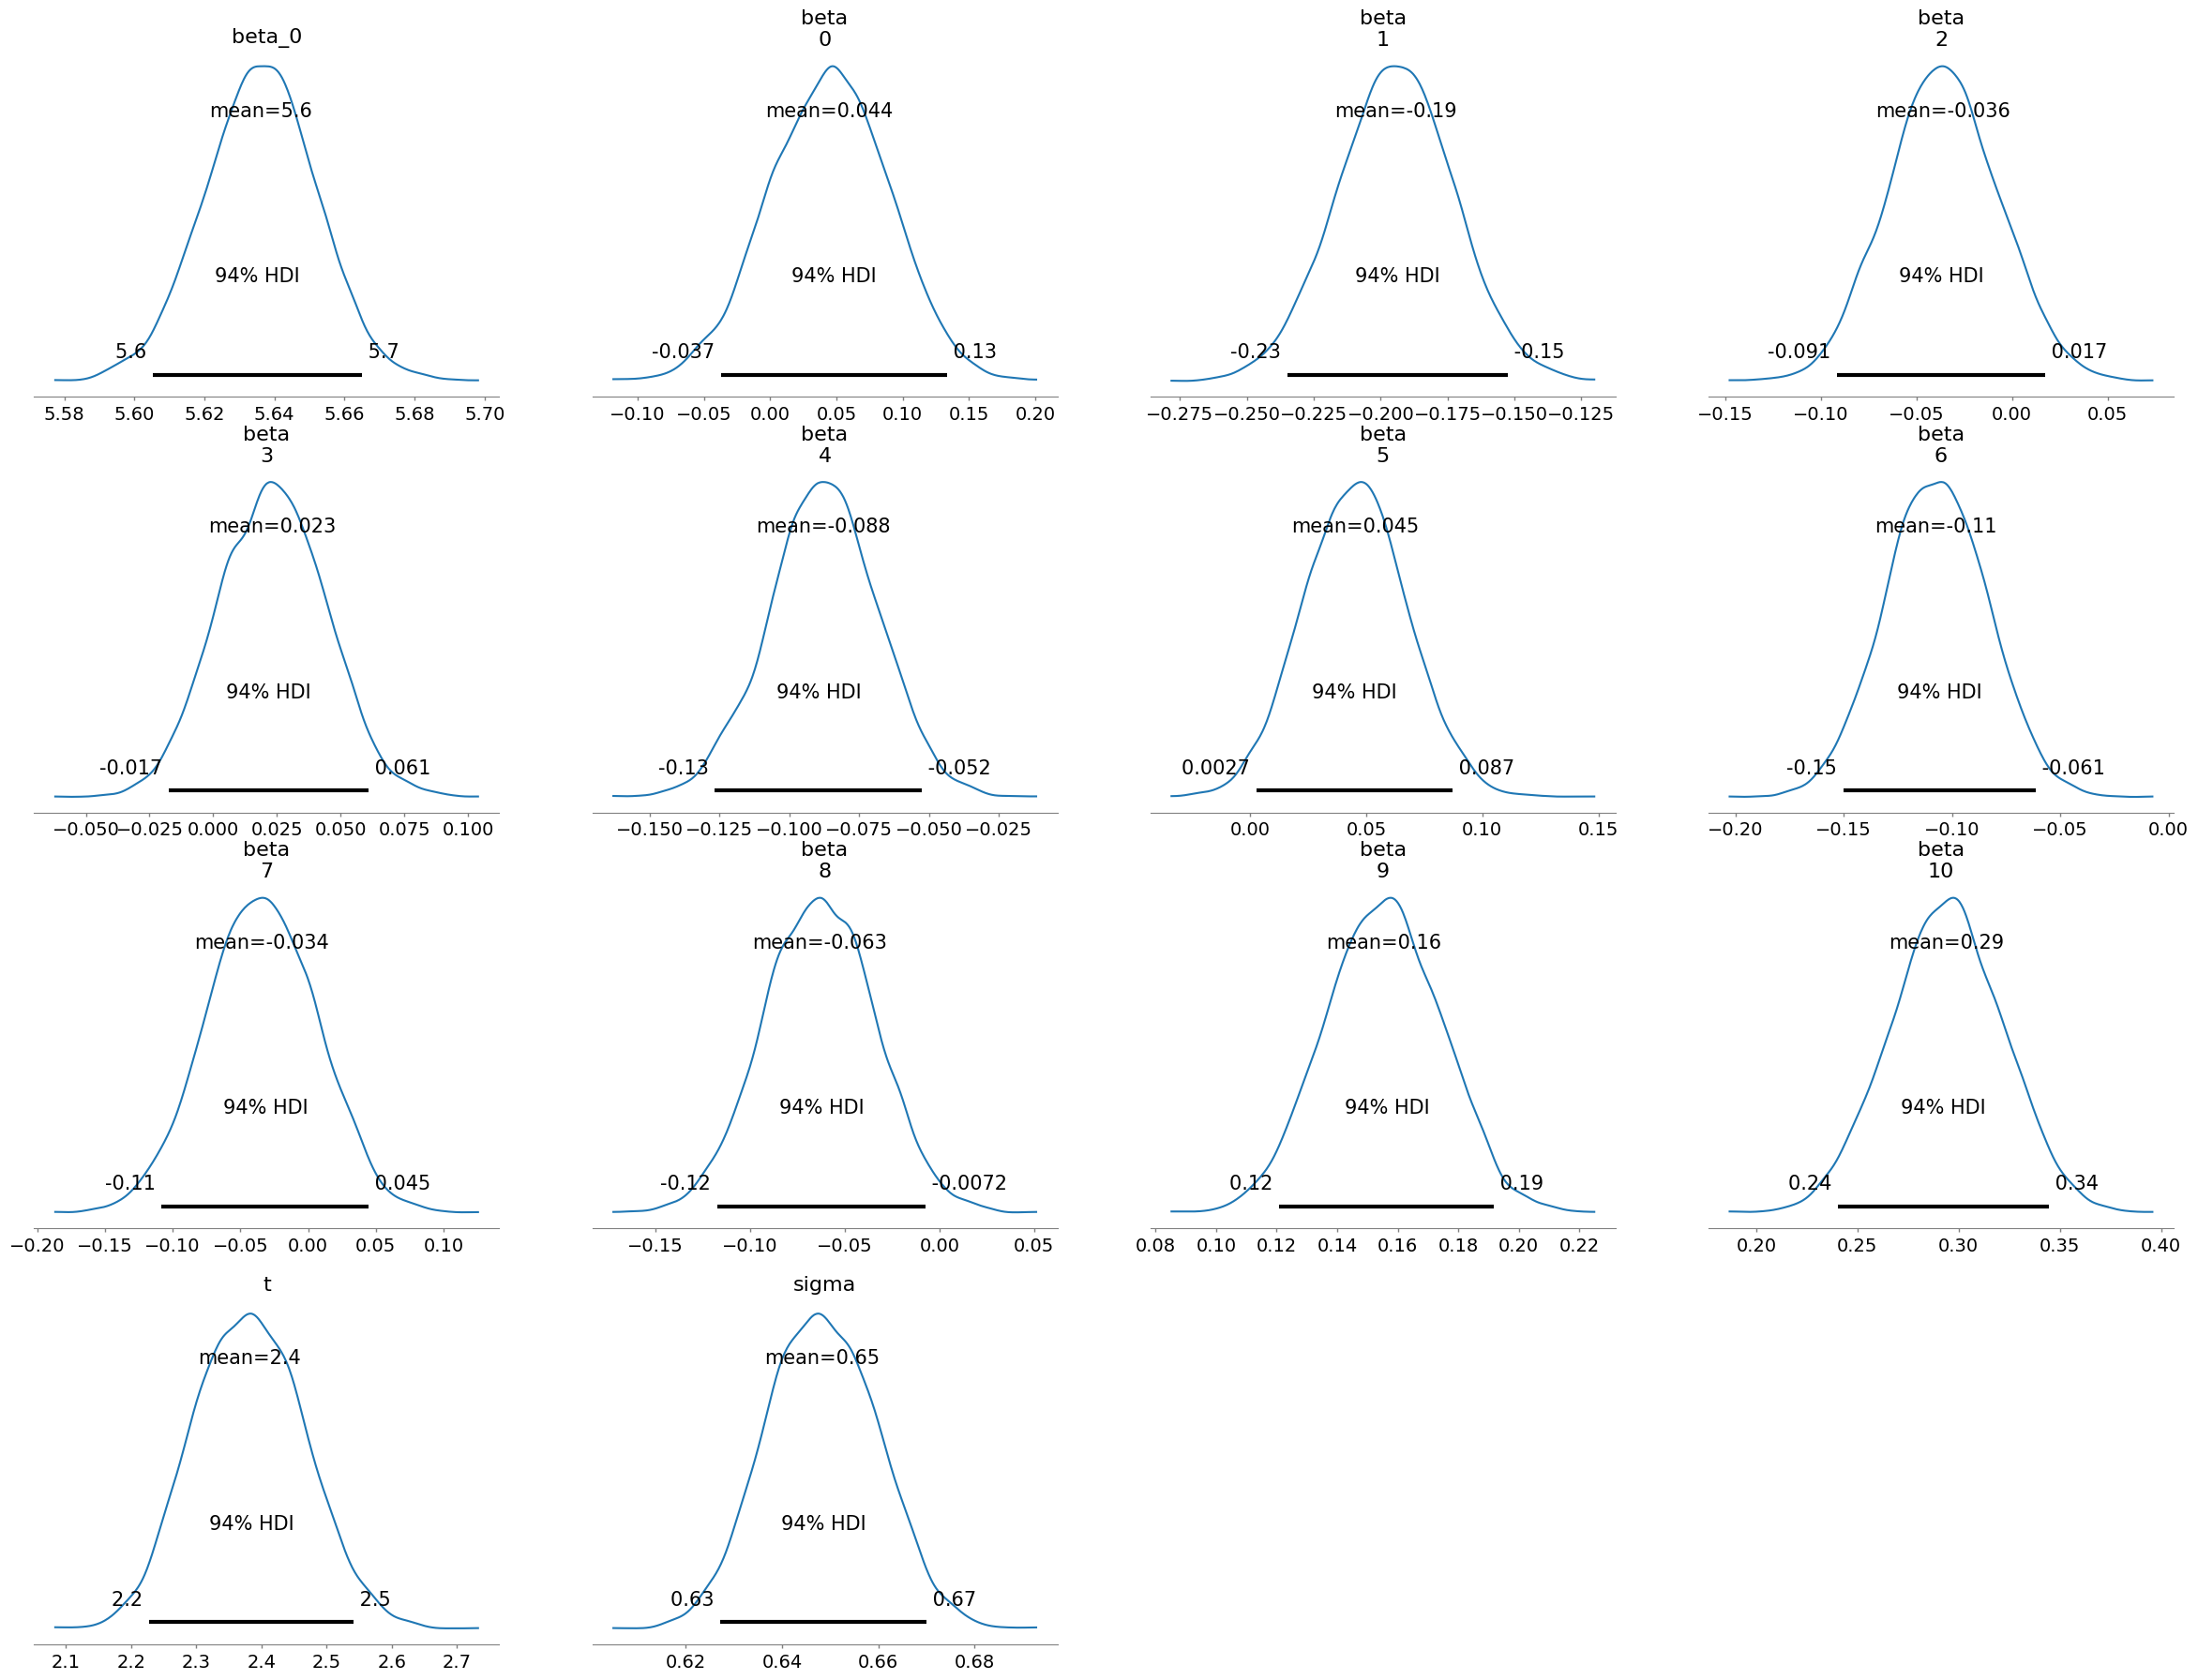

In [11]:
az.plot_posterior(trace, var_names=["beta_0", "beta", "t", "sigma"])
plt.show()

#### 2 Feature

In [24]:
features = ["alcohol", "volatile acidity"]
X_small = df[features]
y = df["quality"].values

In [25]:
scaler_small = StandardScaler()
X_small_scaled = scaler_small.fit_transform(X_small)

X_small_scaled = pd.DataFrame(X_small_scaled, columns=features)

In [26]:
tau_beta = 0.0001
alpha_t = 0.001
beta_t = 0.001

In [27]:
with pm.Model() as bayes_lm_2f:
    
    beta_0 = pm.Normal("beta_0", mu=0, tau=tau_beta)
    
    beta = pm.Normal("beta", mu=0, tau=tau_beta, shape=2)
    
    t = pm.Gamma("t", alpha=alpha_t, beta=beta_t)
    
    sigma = pm.Deterministic("sigma", 1 / pm.math.sqrt(t))
    
    mu = beta_0 + pm.math.dot(X_small_scaled.values, beta)
    
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

In [28]:
with bayes_lm_2f:
    trace_2f = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta, t]


e:\Bayesian\01_Bayesian Linear Regression_MCMC\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 575 seconds.


In [29]:
summary_2f = az.summary(
    trace_2f,
    var_names=["beta_0", "beta", "t", "sigma"]
)

summary_2f

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,5.636,0.017,5.605,5.668,0.000,0.000,7913.0,6306.0,1.0
beta[0],0.334,0.017,0.302,0.365,0.000,0.000,8666.0,6522.0,1.0
beta[1],-0.248,0.017,-0.279,-0.216,0.000,0.000,8589.0,6614.0,1.0
t,2.242,0.081,2.092,2.396,0.001,0.001,8981.0,5669.0,1.0
sigma,0.668,0.012,0.646,0.691,0.000,0.000,8981.0,5669.0,1.0


這邊算是bayesian MCMC的優點，可以看到其平均值為b1 = 0.334、b2 = -0.248 對照回去02_baseline, 其b1 = 0.332, b2 = -0.235 十分接近，
最重要的是bayesian有提供了貝氏信賴區間:
β1 ∈ [0.30, 0.37]
β2 ∈ [-0.28, -0.22]

不過在計算時間上就算是MCMC的缺點，在兩性狀時尚需要7-8分鐘，而在全性狀時則需要22分


-------------------------
另外當 alcohol = 平均值、volatile acidity = 平均值時
預測 quality ≈ 5.636

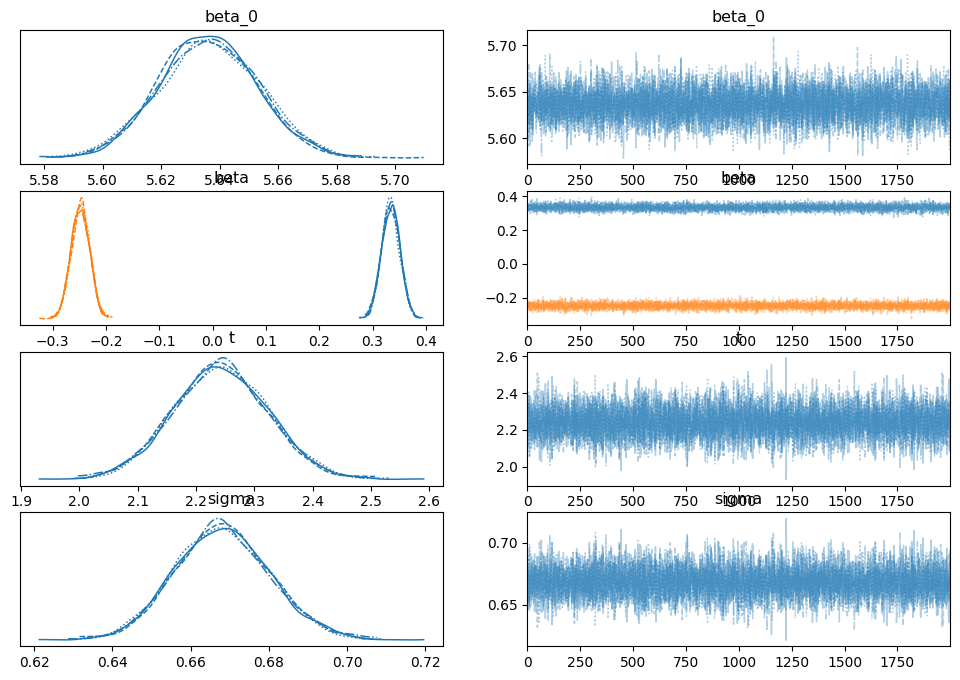

In [30]:
az.plot_trace(trace_2f, var_names=["beta_0", "beta", "t", "sigma"])
plt.show()

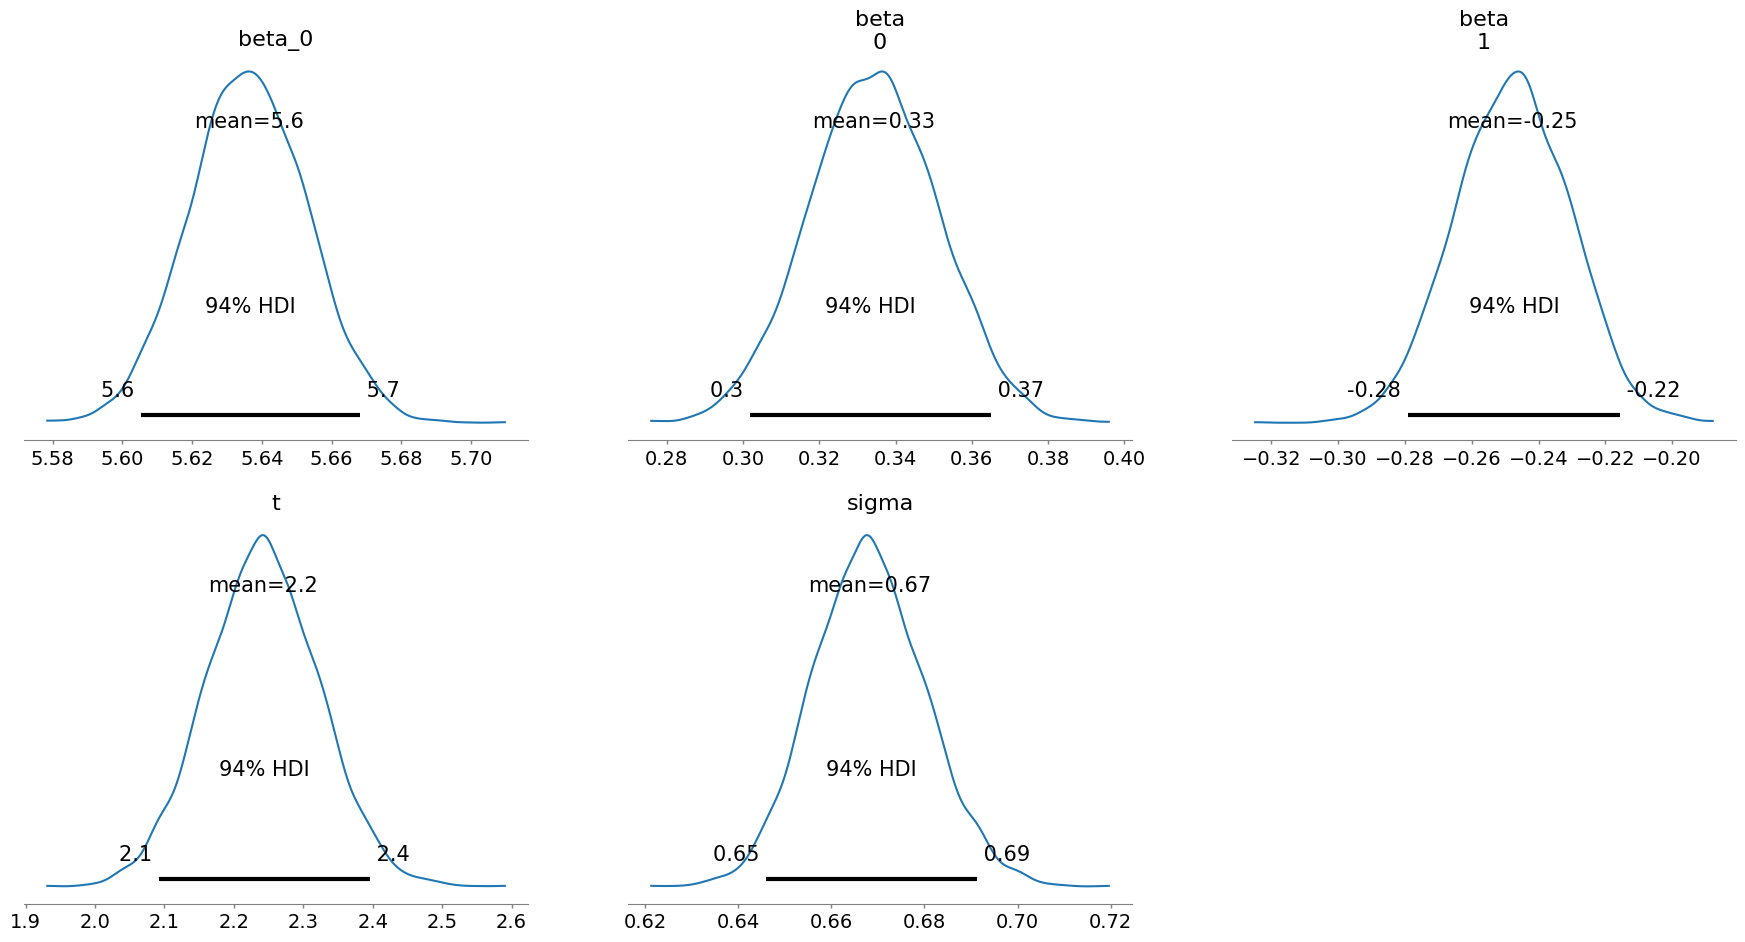

In [31]:
az.plot_posterior(trace_2f, var_names=["beta_0", "beta", "t", "sigma"])
plt.show()

In [32]:
coef_summary = az.summary(trace_2f, var_names=["beta"])
coef_summary["feature"] = features
coef_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,feature
beta[0],0.334,0.017,0.302,0.365,0.0,0.0,8666.0,6522.0,1.0,alcohol
beta[1],-0.248,0.017,-0.279,-0.216,0.0,0.0,8589.0,6614.0,1.0,volatile acidity


In [33]:
posterior = trace_2f.posterior

beta_0_samples = posterior["beta_0"].values.flatten()
beta_samples = posterior["beta"].values.reshape(-1, 2)
t_samples = posterior["t"].values.flatten()

In [34]:
alcohol_raw = X_small["alcohol"].values
alcohol_grid = np.linspace(alcohol_raw.min(), alcohol_raw.max(), 100)

alcohol_mean = X_small["alcohol"].mean()
alcohol_std = X_small["alcohol"].std()

alcohol_grid_scaled = (alcohol_grid - alcohol_mean) / alcohol_std

In [35]:
volatile_fixed_scaled = 0

In [36]:
y_lines = []
y_pred_samples = []

n_draws = min(2000, len(beta_0_samples))

for i in range(n_draws):
    mu = (
        beta_0_samples[i]
        + beta_samples[i, 0] * alcohol_grid_scaled
        + beta_samples[i, 1] * volatile_fixed_scaled
    )
    
    y_lines.append(mu)
    
    sigma_i = 1 / np.sqrt(t_samples[i])
    y_sample = np.random.normal(mu, sigma_i, size=len(alcohol_grid))
    y_pred_samples.append(y_sample)

y_lines = np.array(y_lines)
y_pred_samples = np.array(y_pred_samples)

mean_line = np.mean(y_lines, axis=0)
lower_blue = np.percentile(y_lines, 2.5, axis=0)
upper_blue = np.percentile(y_lines, 97.5, axis=0)

lower_red = np.percentile(y_pred_samples, 2.5, axis=0)
upper_red = np.percentile(y_pred_samples, 97.5, axis=0)

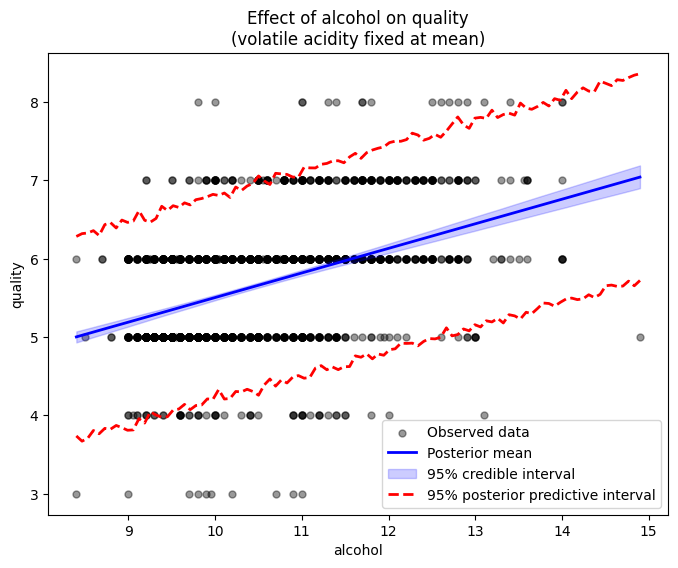

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_small["alcohol"],
    y,
    color="black",
    alpha=0.4,
    s=25,
    label="Observed data"
)

plt.plot(alcohol_grid, mean_line, color="blue", linewidth=2, label="Posterior mean")

plt.fill_between(
    alcohol_grid,
    lower_blue,
    upper_blue,
    color="blue",
    alpha=0.2,
    label="95% credible interval"
)

plt.plot(
    alcohol_grid,
    lower_red,
    color="red",
    linestyle="--",
    linewidth=2,
    label="95% posterior predictive interval"
)
plt.plot(
    alcohol_grid,
    upper_red,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("alcohol")
plt.ylabel("quality")
plt.title("Effect of alcohol on quality\n(volatile acidity fixed at mean)")
plt.legend()
plt.show()

In [38]:
volatile_raw = X_small["volatile acidity"].values
volatile_grid = np.linspace(volatile_raw.min(), volatile_raw.max(), 100)

volatile_mean = X_small["volatile acidity"].mean()
volatile_std = X_small["volatile acidity"].std()

volatile_grid_scaled = (volatile_grid - volatile_mean) / volatile_std

alcohol_fixed_scaled = 0

In [39]:
y_lines_v = []
y_pred_samples_v = []

for i in range(n_draws):
    mu = (
        beta_0_samples[i]
        + beta_samples[i, 0] * alcohol_fixed_scaled
        + beta_samples[i, 1] * volatile_grid_scaled
    )
    
    y_lines_v.append(mu)
    
    sigma_i = 1 / np.sqrt(t_samples[i])
    y_sample = np.random.normal(mu, sigma_i, size=len(volatile_grid))
    y_pred_samples_v.append(y_sample)

y_lines_v = np.array(y_lines_v)
y_pred_samples_v = np.array(y_pred_samples_v)

mean_line_v = np.mean(y_lines_v, axis=0)
lower_blue_v = np.percentile(y_lines_v, 2.5, axis=0)
upper_blue_v = np.percentile(y_lines_v, 97.5, axis=0)

lower_red_v = np.percentile(y_pred_samples_v, 2.5, axis=0)
upper_red_v = np.percentile(y_pred_samples_v, 97.5, axis=0)

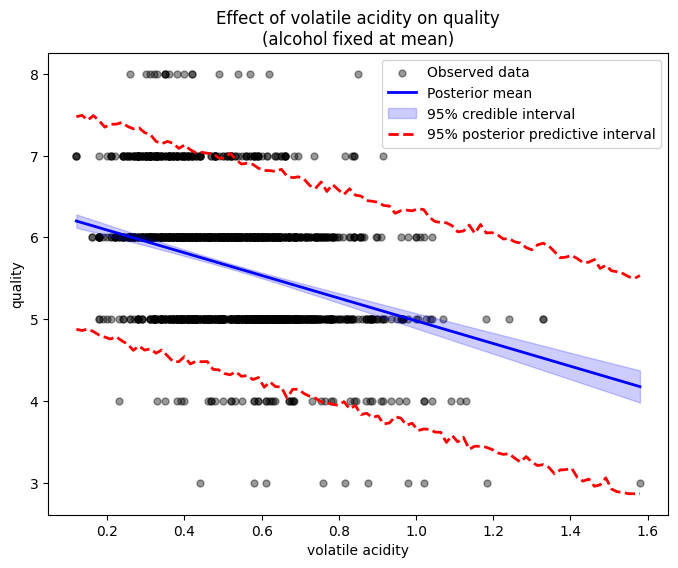

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_small["volatile acidity"],
    y,
    color="black",
    alpha=0.4,
    s=25,
    label="Observed data"
)

plt.plot(volatile_grid, mean_line_v, color="blue", linewidth=2, label="Posterior mean")

plt.fill_between(
    volatile_grid,
    lower_blue_v,
    upper_blue_v,
    color="blue",
    alpha=0.2,
    label="95% credible interval"
)

plt.plot(
    volatile_grid,
    lower_red_v,
    color="red",
    linestyle="--",
    linewidth=2,
    label="95% posterior predictive interval"
)
plt.plot(
    volatile_grid,
    upper_red_v,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("volatile acidity")
plt.ylabel("quality")
plt.title("Effect of volatile acidity on quality\n(alcohol fixed at mean)")
plt.legend()
plt.show()

後驗結果解釋（Posterior Interpretation）

貝氏迴歸結果顯示，酒精含量（alcohol）對葡萄酒品質具有顯著的正向影響，而揮發性酸度（volatile acidity）則具有顯著的負向影響。

這兩個係數的可信區間（credible intervals）皆不包含 0，表示有強烈證據支持它們對品質的影響。

後驗平均（posterior mean）指出，當酒精含量增加一個標準差時，葡萄酒品質約提升 0.33；相對地，當揮發性酸度增加一個標準差時，品質約下降 0.25。

儘管這兩個變數具有明顯影響，但殘差標準差仍約為 0.67，顯示仍需引入其他變數，才能更完整地解釋葡萄酒品質的變異性。